# Coursework 1

This notebook is intended to be used as a starting point for your experiments. The instructions can be found in the MLP2025_26_CW1_Spec.pdf (see Learn,  Assignment Submission, Coursework 1). The methods provided here are just helper functions. If you want more complex graphs such as side by side comparisons of different experiments you should learn more about matplotlib and implement them. Before each experiment remember to re-initialize neural network weights and reset the data providers so you get a properly initialized experiment. For each experiment try to keep most hyperparameters the same except the one under investigation so you can understand what the effects of each are.

## Training Boilerplate

Use the below code as a boilerplate to start your experiments. You can add more cells or change the code as you see fit.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import logging
import sys, os

os.chdir("..")
print(os.getcwd())

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser

d:\MSc\MLP\mlpractical


In [4]:
%matplotlib inline
plt.style.use('ggplot')

def train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True):
    
    # As well as monitoring the error over training also monitor classification
    # accuracy i.e. proportion of most-probable predicted classes being equal to targets
    data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    # Use the created objects to initialise a new Optimiser instance.
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, data_monitors, notebook=notebook)

    # Run the optimiser for num_epochs epochs (full passes through the training set)
    # printing statistics every epoch.
    stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

    # Plot the change in the validation and training set error over training.
    fig_1 = plt.figure(figsize=(8, 4))
    ax_1 = fig_1.add_subplot(111)
    for k in ['error(train)', 'error(valid)']:
        ax_1.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_1.legend(loc=0)
    ax_1.set_xlabel('Epoch number')
    ax_1.set_ylabel('Error')

    # Plot the change in the validation and training set accuracy over training.
    fig_2 = plt.figure(figsize=(8, 4))
    ax_2 = fig_2.add_subplot(111)
    for k in ['acc(train)', 'acc(valid)']:
        ax_2.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_2.legend(loc=0)
    ax_2.set_xlabel('Epoch number')
    ax_2.set_xlabel('Accuracy')

    grad_plot, grad_ax = optimiser.plot_grad_flow()

    return stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax

In [5]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]
print(os.getcwd())
os.environ['MLP_DATA_DIR'] = os.path.join(os.getcwd(), 'mlpractical/data')


# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

d:\MSc\MLP\mlpractical
KeysView(NpzFile 'd:\\MSc\\MLP\\mlpractical\\mlpractical/data\\emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile 'd:\\MSc\\MLP\\mlpractical\\mlpractical/data\\emnist-valid.npz' with keys: inputs, targets)


Note: you may need to restart the kernel to use updated packages.















































Ep Prog: 100%|██████████| 1000/1000 [00:04<00:00, 205.46it/s]
Epoch 1: 4.9s to complete
    error(train)=7.54e-01, acc(train)=7.74e-01, error(valid)=7.74e-01, acc(valid)=7.68e-01





































Ep Prog: 100%|██████████| 1000/1000 [00:03<00:00, 265.79it/s]
Epoch 2: 3.8s to complete
    error(train)=5.80e-01, acc(train)=8.14e-01, error(valid)=6.18e-01, acc(valid)=8.05e-01










































































































































































Ep Prog: 100%|██████████| 1000/1000 [00:19<00:00, 51.41it/s]
Epoch 3: 19.5s to complete
    error(train)=5.17e-01, acc(train)=8.31e-01, error(valid)=5.75e-01, acc(valid)=8.15e-01











































































































































































Ep Prog: 100%|██████████| 1000/1000 [00:

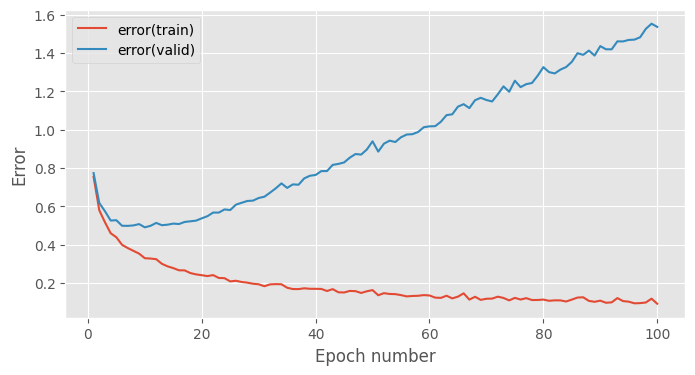

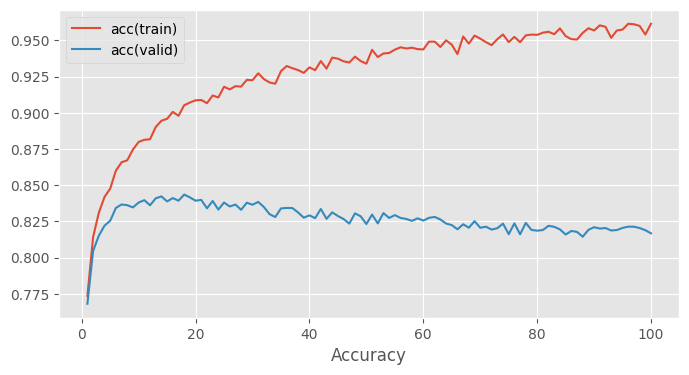

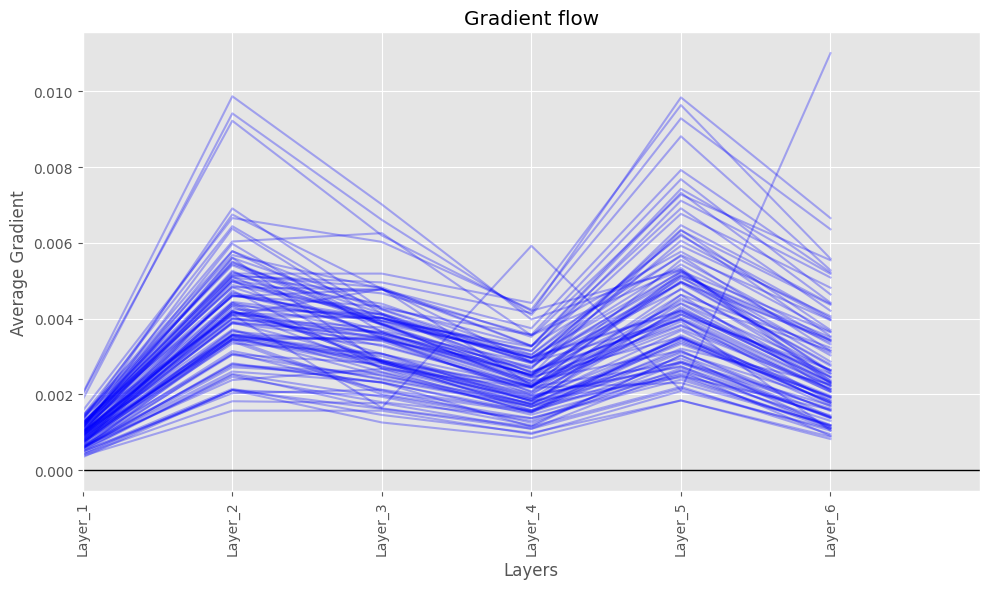

In [39]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.

%pip install tqdm

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=False)

In [40]:
# Saving the figures
fig_1.savefig('baseline_error.pdf')
fig_2.savefig('baseline_accuracy.pdf')

# Printing the results
print("\nTraining completed")
print("Time taken:", run_time, "seconds")
print("Final training error:", stats[-1, keys['error(train)']])
print("Final validation error:", stats[-1, keys['error(valid)']])
print("Final training accuracy:", stats[-1, keys['acc(train)']])
print("Final validation accuracy:", stats[-1, keys['acc(valid)']])


Training completed
Time taken: 731.4112868309021 seconds
Final training error: 0.09229114692759001
Final validation error: 1.5364491856256994
Final training accuracy: 0.9615300000000129
Final validation accuracy: 0.8167721518987344


Training with 32 hidden units






























Ep Prog: 100%|██████████| 1000/1000 [00:01<00:00, 773.81it/s]
Epoch 1: 1.3s to complete
    error(train)=1.23e+00, acc(train)=6.56e-01, error(valid)=1.24e+00, acc(valid)=6.51e-01



















Ep Prog: 100%|██████████| 1000/1000 [00:00<00:00, 1142.55it/s]
Epoch 2: 0.9s to complete
    error(train)=1.10e+00, acc(train)=6.90e-01, error(valid)=1.13e+00, acc(valid)=6.84e-01





















Ep Prog: 100%|██████████| 1000/1000 [00:01<00:00, 938.27it/s]
Epoch 3: 1.1s to complete
    error(train)=1.03e+00, acc(train)=7.10e-01, error(valid)=1.05e+00, acc(valid)=7.04e-01

























Ep Prog: 100%|██████████| 1000/1000 [00:01<00:00, 809.48it/s]
Epoch 4: 1.2s to complete
    error(train)=9.70e-01, acc(train)=7.22e-01, error(valid)=1.00e+00, acc(valid)=7.13e-01























Ep Prog: 100%|██████████| 1000/1000 [00:01<00:00, 912.56it/s]
Epoch 5: 1.1s to complete
    error(train)=9.17e-01, acc(train)=7.35e-01, error(valid)=9.57e-01, acc(vali

Final training error: 0.5523022794902582
Final validation error: 0.6970392296602217
Final training accuracy: 0.8229599999999994
Final validation accuracy: 0.7870253164556961


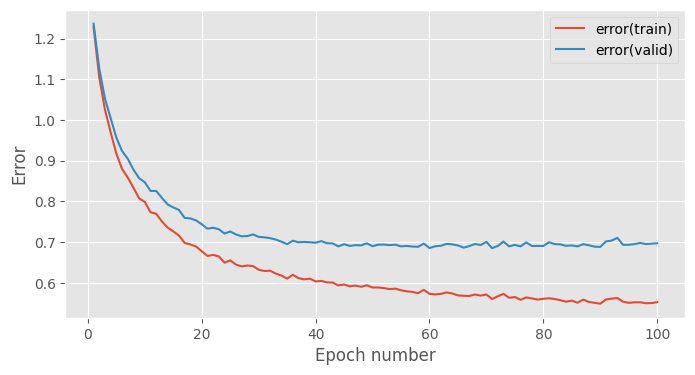

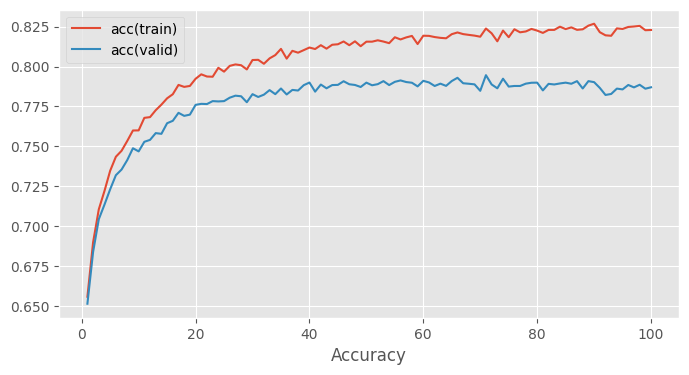

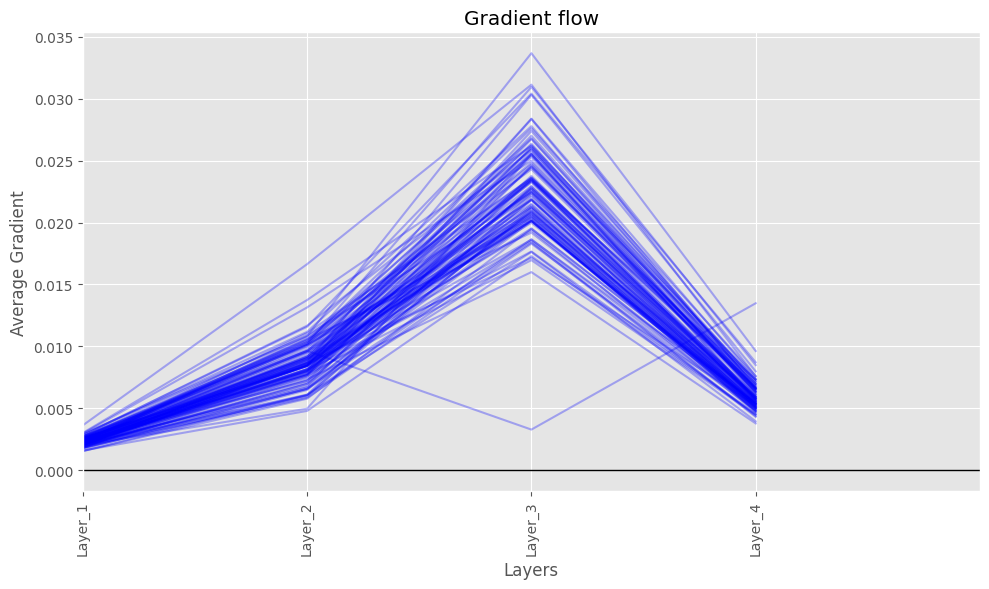

In [43]:
# Experimenting with different numbers of hidden units
hidden_units_list = [32, 64, 128]

# Store results
results_32 = None
results_64 = None
results_128 = None

# Train with 32 hidden units
print("Training with 32 hidden units")
train_data.reset()
valid_data.reset()

hidden_dim = 32
layer1 = AffineLayer(input_dim, hidden_dim, weights_init, biases_init)
activation1 = ReluLayer()
layer2 = AffineLayer(hidden_dim, output_dim, weights_init, biases_init)

layers = [layer1, activation1, layer2]
model = MultipleLayerModel(layers)

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=0.001)

stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, 100, 1, notebook=False)

results_32 = {}
results_32['stats'] = stats
results_32['keys'] = keys

fig_1.savefig('width_32units_error.pdf')
fig_2.savefig('width_32units_accuracy.pdf')

print("Final training error:", stats[-1, keys['error(train)']])
print("Final validation error:", stats[-1, keys['error(valid)']])
print("Final training accuracy:", stats[-1, keys['acc(train)']])
print("Final validation accuracy:", stats[-1, keys['acc(valid)']])

Training with 64 hidden units
































Ep Prog: 100%|██████████| 1000/1000 [00:01<00:00, 676.40it/s]
Epoch 1: 1.5s to complete
    error(train)=1.05e+00, acc(train)=7.03e-01, error(valid)=1.07e+00, acc(valid)=7.01e-01































Ep Prog: 100%|██████████| 1000/1000 [00:01<00:00, 565.32it/s]
Epoch 2: 1.8s to complete
    error(train)=8.90e-01, acc(train)=7.40e-01, error(valid)=9.16e-01, acc(valid)=7.32e-01



























Ep Prog: 100%|██████████| 1000/1000 [00:01<00:00, 764.36it/s]
Epoch 3: 1.3s to complete
    error(train)=7.79e-01, acc(train)=7.69e-01, error(valid)=8.15e-01, acc(valid)=7.58e-01





























Ep Prog: 100%|██████████| 1000/1000 [00:01<00:00, 674.34it/s]
Epoch 4: 1.5s to complete
    error(train)=7.13e-01, acc(train)=7.86e-01, error(valid)=7.59e-01, acc(valid)=7.70e-01































Ep Prog: 100%|██████████| 1000/1000 [00:01<00:00, 674.93it/s]
Epoch 5: 1.5s to complete
    error(train)=6.83e-01, acc(train)=7.90e-01, 

Final training error: 0.3578760510788125
Final validation error: 0.7113704377585263
Final training accuracy: 0.8745599999999988
Final validation accuracy: 0.7976582278481011


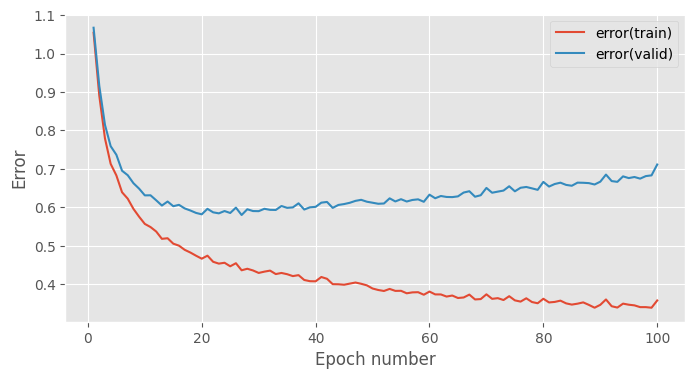

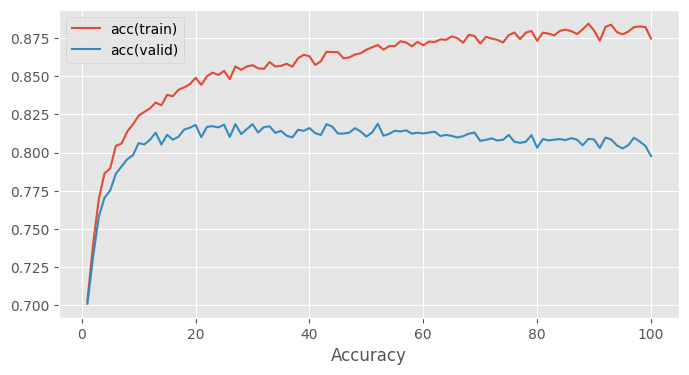

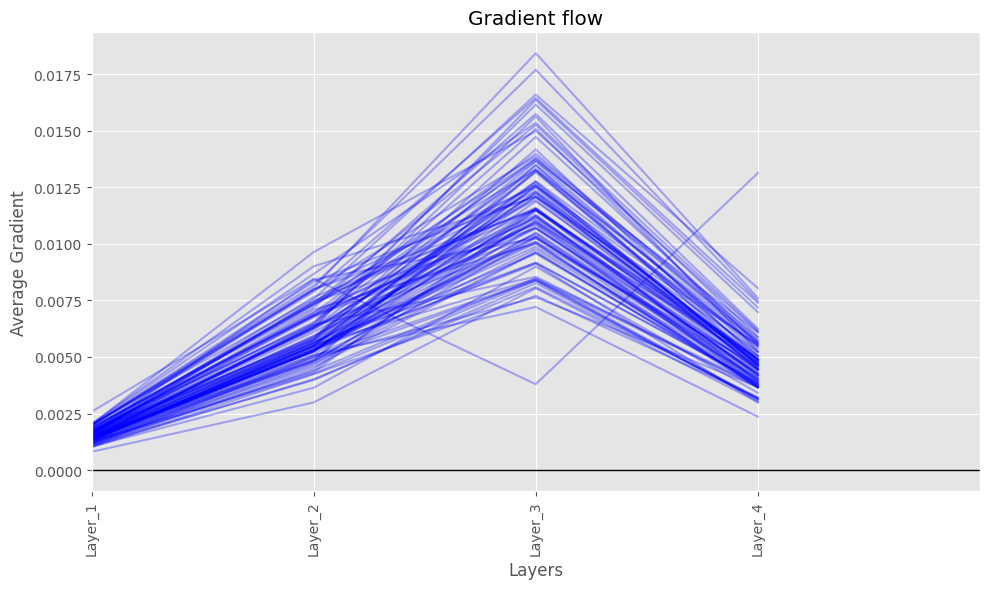

In [44]:
# 64 hidden units
print("Training with 64 hidden units")
train_data.reset()
valid_data.reset()

hidden_dim = 64
layer1 = AffineLayer(input_dim, hidden_dim, weights_init, biases_init)
activation1 = ReluLayer()
layer2 = AffineLayer(hidden_dim, output_dim, weights_init, biases_init)

layers = [layer1, activation1, layer2]
model = MultipleLayerModel(layers)

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=0.001)

stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, 100, 1, notebook=False)

results_64 = {}
results_64['stats'] = stats
results_64['keys'] = keys

fig_1.savefig('width_64units_error.pdf')
fig_2.savefig('width_64units_accuracy.pdf')

print("Final training error:", stats[-1, keys['error(train)']])
print("Final validation error:", stats[-1, keys['error(valid)']])
print("Final training accuracy:", stats[-1, keys['acc(train)']])
print("Final validation accuracy:", stats[-1, keys['acc(valid)']])

Training with 128 hidden units




































































































Ep Prog: 100%|██████████| 1000/1000 [00:04<00:00, 200.04it/s]
Epoch 1: 5.0s to complete
    error(train)=9.13e-01, acc(train)=7.38e-01, error(valid)=9.34e-01, acc(valid)=7.32e-01







































































































Ep Prog: 100%|██████████| 1000/1000 [00:05<00:00, 186.03it/s]
Epoch 2: 5.4s to complete
    error(train)=7.17e-01, acc(train)=7.86e-01, error(valid)=7.49e-01, acc(valid)=7.80e-01









































































































Ep Prog: 100%|██████████| 1000/1000 [00:05<00:00, 179.43it/s]
Epoch 3: 5.6s to complete
    error(train)=6.11e-01, acc(train)=8.12e-01, error(valid)=6.53e-01, acc(valid)=8.03e-01





































































































Ep Prog: 100%|██████████| 1000/1000 [00:05<00:00, 190.93

Final training error: 0.1573953278195543
Final validation error: 0.9398370812469343
Final training accuracy: 0.9397000000000028
Final validation accuracy: 0.8117088607594939


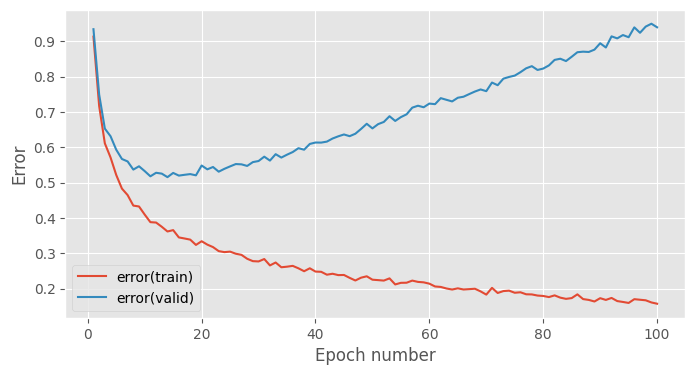

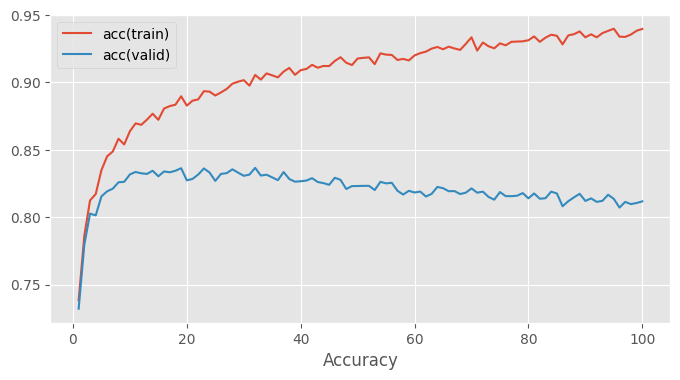

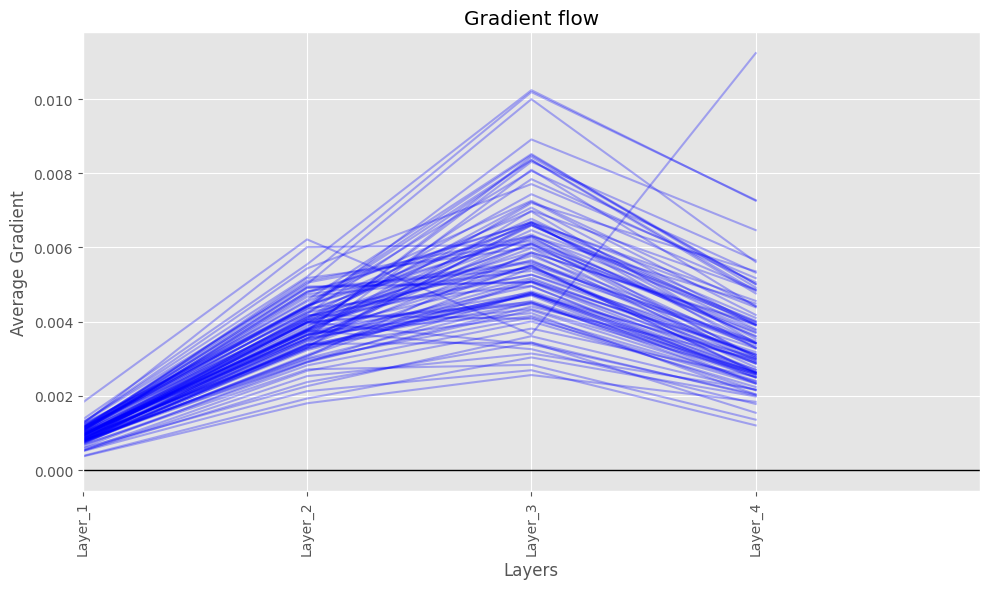

In [45]:
# 128 hidden units
print("Training with 128 hidden units")
train_data.reset()
valid_data.reset()

hidden_dim = 128
layer1 = AffineLayer(input_dim, hidden_dim, weights_init, biases_init)
activation1 = ReluLayer()
layer2 = AffineLayer(hidden_dim, output_dim, weights_init, biases_init)

layers = [layer1, activation1, layer2]
model = MultipleLayerModel(layers)

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=0.001)

stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, 100, 1, notebook=False)

results_128 = {}
results_128['stats'] = stats
results_128['keys'] = keys

fig_1.savefig('width_128units_error.pdf')
fig_2.savefig('width_128units_accuracy.pdf')

print("Final training error:", stats[-1, keys['error(train)']])
print("Final validation error:", stats[-1, keys['error(valid)']])
print("Final training accuracy:", stats[-1, keys['acc(train)']])
print("Final validation accuracy:", stats[-1, keys['acc(valid)']])

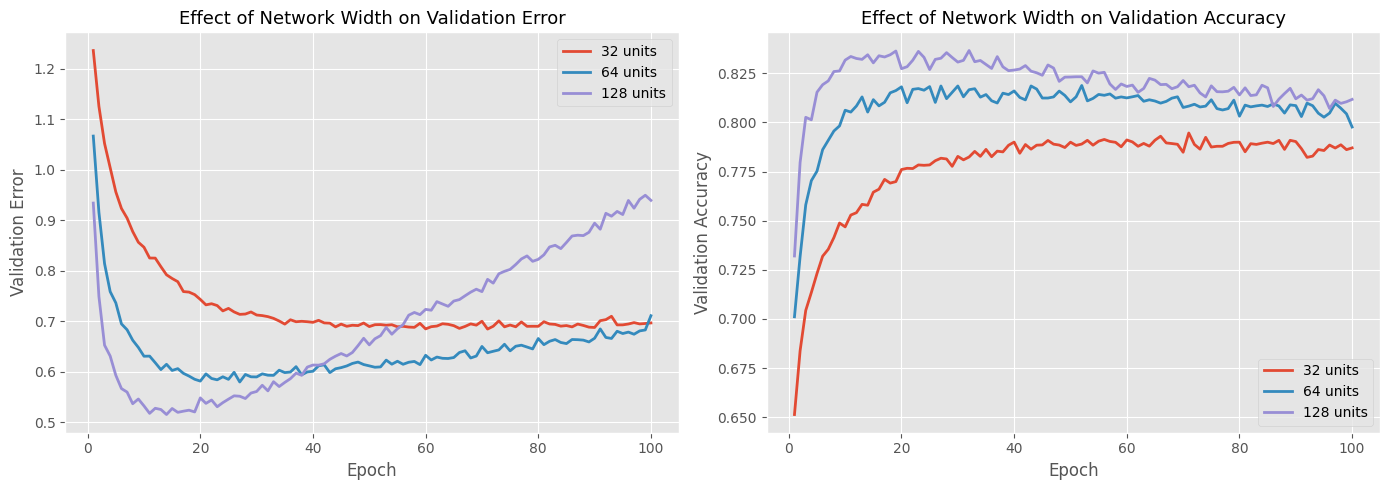

In [46]:
# comparison plots
fig = plt.figure(figsize=(14, 5))

# validation errors
ax1 = fig.add_subplot(1, 2, 1)

stats_32 = results_32['stats']
keys_32 = results_32['keys']
epochs_32 = np.arange(1, stats_32.shape[0])
valid_error_32 = stats_32[1:, keys_32['error(valid)']]
ax1.plot(epochs_32, valid_error_32, label='32 units', linewidth=2)

stats_64 = results_64['stats']
keys_64 = results_64['keys']
epochs_64 = np.arange(1, stats_64.shape[0])
valid_error_64 = stats_64[1:, keys_64['error(valid)']]
ax1.plot(epochs_64, valid_error_64, label='64 units', linewidth=2)

stats_128 = results_128['stats']
keys_128 = results_128['keys']
epochs_128 = np.arange(1, stats_128.shape[0])
valid_error_128 = stats_128[1:, keys_128['error(valid)']]
ax1.plot(epochs_128, valid_error_128, label='128 units', linewidth=2)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Validation Error', fontsize=12)
ax1.set_title('Effect of Network Width on Validation Error', fontsize=13)
ax1.legend()
ax1.grid(True)

# validation accuracies
ax2 = fig.add_subplot(1, 2, 2)

valid_acc_32 = stats_32[1:, keys_32['acc(valid)']]
ax2.plot(epochs_32, valid_acc_32, label='32 units', linewidth=2)

valid_acc_64 = stats_64[1:, keys_64['acc(valid)']]
ax2.plot(epochs_64, valid_acc_64, label='64 units', linewidth=2)

valid_acc_128 = stats_128[1:, keys_128['acc(valid)']]
ax2.plot(epochs_128, valid_acc_128, label='128 units', linewidth=2)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Validation Accuracy', fontsize=12)
ax2.set_title('Effect of Network Width on Validation Accuracy', fontsize=13)
ax2.legend()
ax2.grid(True)

fig.tight_layout()
fig.savefig('width_comparison.pdf')
plt.show()

Training with 1 hidden layer








































































Ep Prog: 100%|██████████| 1000/1000 [00:03<00:00, 283.80it/s]
Epoch 1: 3.5s to complete
    error(train)=8.89e-01, acc(train)=7.44e-01, error(valid)=9.12e-01, acc(valid)=7.36e-01









































































Ep Prog: 100%|██████████| 1000/1000 [00:03<00:00, 270.11it/s]
Epoch 2: 3.7s to complete
    error(train)=7.00e-01, acc(train)=7.86e-01, error(valid)=7.39e-01, acc(valid)=7.75e-01

































































Ep Prog: 100%|██████████| 1000/1000 [00:03<00:00, 310.30it/s]
Epoch 3: 3.2s to complete
    error(train)=5.97e-01, acc(train)=8.15e-01, error(valid)=6.44e-01, acc(valid)=8.00e-01



























































Ep Prog: 100%|██████████| 1000/1000 [00:03<00:00, 331.46it/s]
Epoch 4: 3.0s to complete
    error(train)=5.39e-01, acc(train)=8.30e-01, error(valid)=6.04e-01, acc(valid)=8.11e-01



















Final training error: 0.1600086476459929
Final validation error: 0.9568117274708956
Final training accuracy: 0.936620000000004
Final validation accuracy: 0.8013924050632906


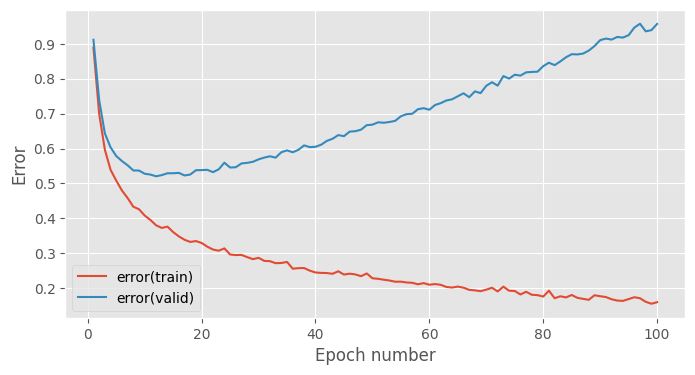

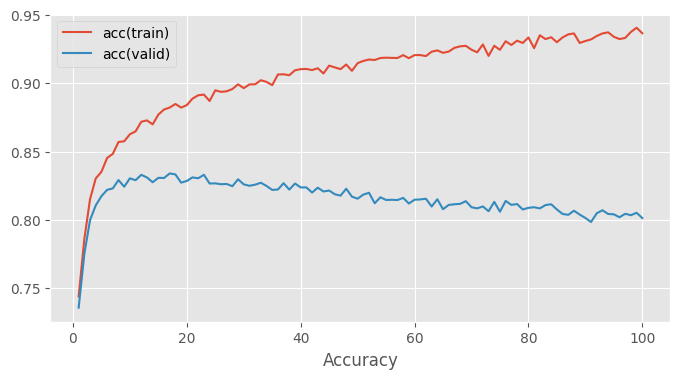

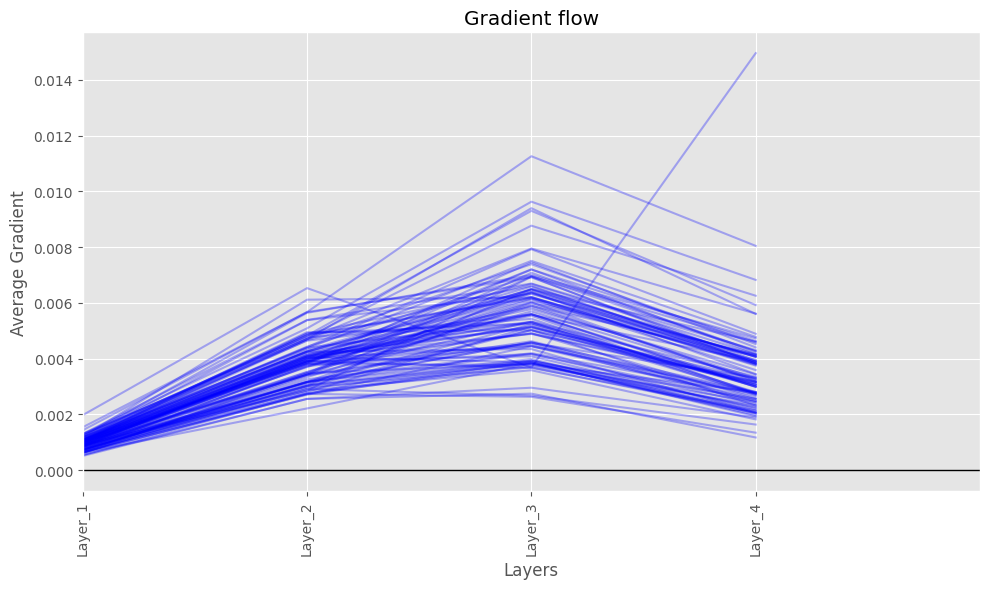

In [47]:
# 1 hidden layer
print("Training with 1 hidden layer")
train_data.reset()
valid_data.reset()

layer1 = AffineLayer(input_dim, 128, weights_init, biases_init)
activation1 = ReluLayer()
layer_out = AffineLayer(128, output_dim, weights_init, biases_init)

layers = [layer1, activation1, layer_out]
model = MultipleLayerModel(layers)

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=0.001)

stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, 100, 1, notebook=False)

results_1layer = {}
results_1layer['stats'] = stats
results_1layer['keys'] = keys

fig_1.savefig('depth_1layer_error.pdf')
fig_2.savefig('depth_1layer_accuracy.pdf')

print("Final training error:", stats[-1, keys['error(train)']])
print("Final validation error:", stats[-1, keys['error(valid)']])
print("Final training accuracy:", stats[-1, keys['acc(train)']])
print("Final validation accuracy:", stats[-1, keys['acc(valid)']])

Training with 2 hidden layers
























































































































































































































































Ep Prog: 100%|██████████| 1000/1000 [00:13<00:00, 73.99it/s]
Epoch 1: 13.5s to complete
    error(train)=7.58e-01, acc(train)=7.71e-01, error(valid)=7.80e-01, acc(valid)=7.64e-01























































































Ep Prog: 100%|██████████| 1000/1000 [00:04<00:00, 218.82it/s]
Epoch 2: 4.6s to complete
    error(train)=5.93e-01, acc(train)=8.12e-01, error(valid)=6.35e-01, acc(valid)=7.98e-01















































































Ep Prog: 100%|██████████| 1000/1000 [00:04<00:00, 233.36it/s]
Epoch 3: 4.3s to complete
    error(train)=5.10e-01, acc(train)=8.33e-01, error(valid)=5.69e-01, acc(valid)=8.18e-01





















































Final training error: 0.08657028558054021
Final validation error: 1.5765327478086164
Final training accuracy: 0.9644500000000129
Final validation accuracy: 0.8186708860759492


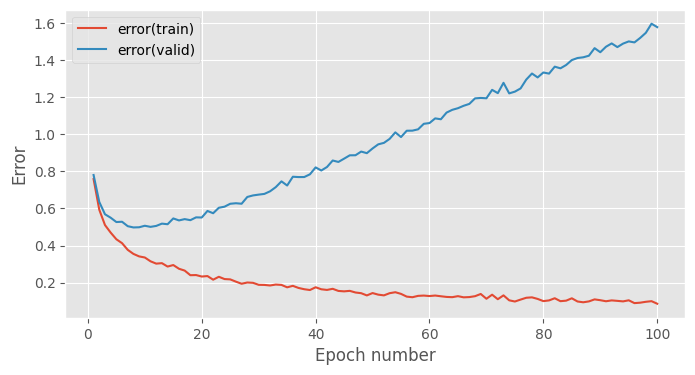

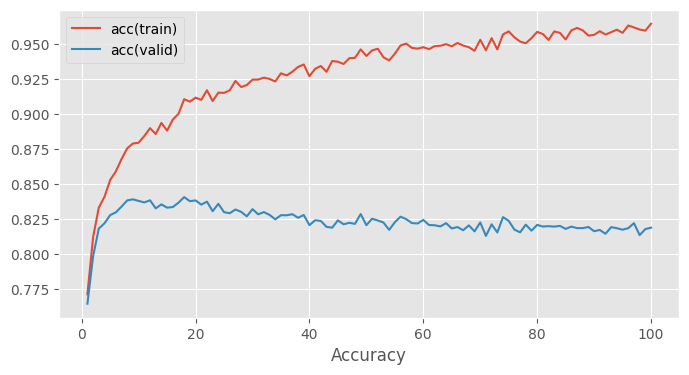

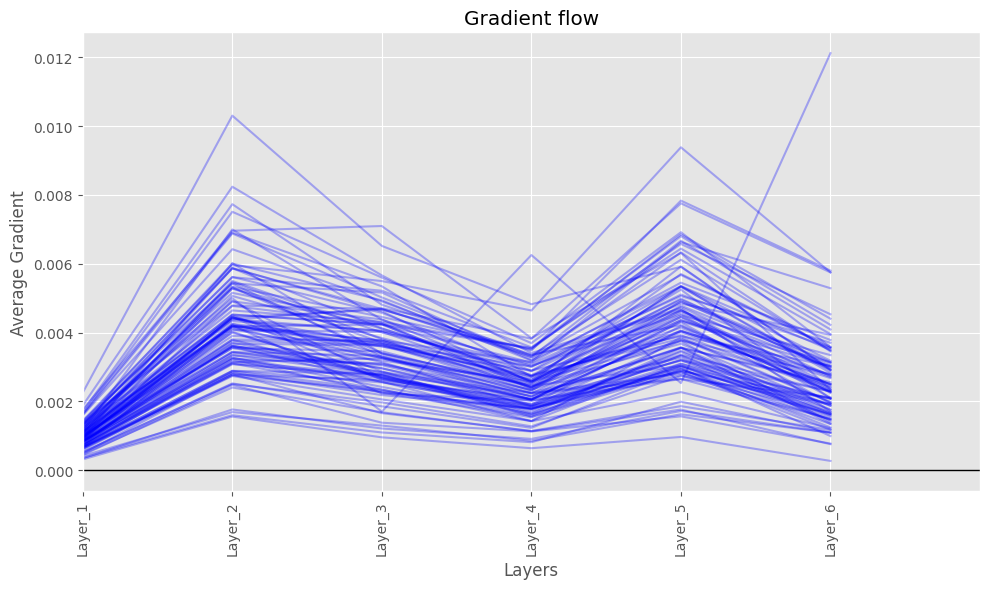

In [48]:
# 2 hidden layers
print("Training with 2 hidden layers")
train_data.reset()
valid_data.reset()

layer1 = AffineLayer(input_dim, 128, weights_init, biases_init)
activation1 = ReluLayer()
layer2 = AffineLayer(128, 128, weights_init, biases_init)
activation2 = ReluLayer()
layer_out = AffineLayer(128, output_dim, weights_init, biases_init)

layers = [layer1, activation1, layer2, activation2, layer_out]
model = MultipleLayerModel(layers)

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=0.001)

stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, 100, 1, notebook=False)

results_2layer = {}
results_2layer['stats'] = stats
results_2layer['keys'] = keys

fig_1.savefig('depth_2layer_error.pdf')
fig_2.savefig('depth_2layer_accuracy.pdf')

print("Final training error:", stats[-1, keys['error(train)']])
print("Final validation error:", stats[-1, keys['error(valid)']])
print("Final training accuracy:", stats[-1, keys['acc(train)']])
print("Final validation accuracy:", stats[-1, keys['acc(valid)']])

Training with 3 hidden layers






























































































Ep Prog: 100%|██████████| 1000/1000 [00:04<00:00, 202.32it/s]
Epoch 1: 5.0s to complete
    error(train)=6.93e-01, acc(train)=7.82e-01, error(valid)=7.19e-01, acc(valid)=7.75e-01

















































































Ep Prog: 100%|██████████| 1000/1000 [00:04<00:00, 239.50it/s]
Epoch 2: 4.2s to complete
    error(train)=5.55e-01, acc(train)=8.16e-01, error(valid)=6.02e-01, acc(valid)=8.05e-01















































































Ep Prog: 100%|██████████| 1000/1000 [00:03<00:00, 253.95it/s]
Epoch 3: 3.9s to complete
    error(train)=4.83e-01, acc(train)=8.38e-01, error(valid)=5.50e-01, acc(valid)=8.18e-01



















































































Ep Prog: 100%|██████████| 1000/1000 [00:04<00:00, 231.88it/s]
Epoch 4: 4.3s to complete
    error(train)=4.42e-01, acc(train)=8.

Final training error: 0.10867222903837127
Final validation error: 1.684468281037889
Final training accuracy: 0.9577800000000112
Final validation accuracy: 0.8178481012658224


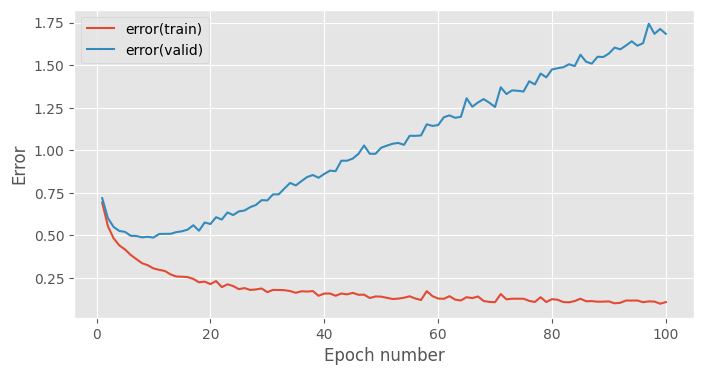

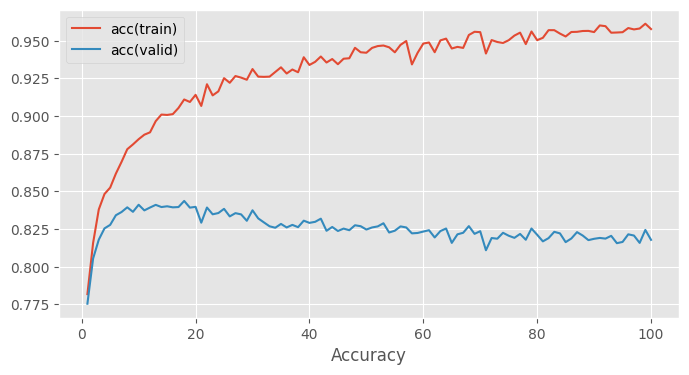

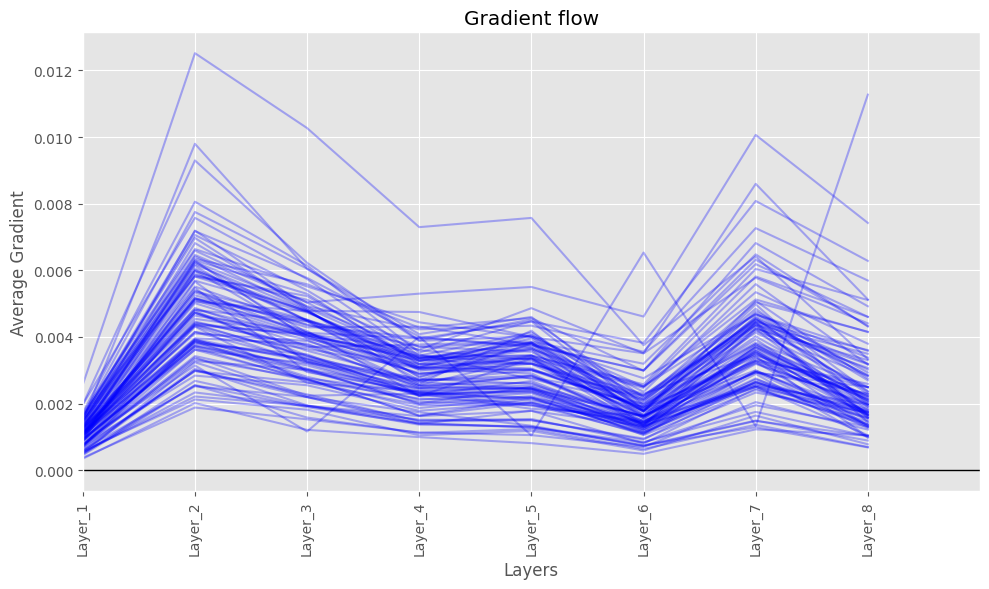

In [49]:
# 3 hidden layers
print("Training with 3 hidden layers")
train_data.reset()
valid_data.reset()

layer1 = AffineLayer(input_dim, 128, weights_init, biases_init)
activation1 = ReluLayer()
layer2 = AffineLayer(128, 128, weights_init, biases_init)
activation2 = ReluLayer()
layer3 = AffineLayer(128, 128, weights_init, biases_init)
activation3 = ReluLayer()
layer_out = AffineLayer(128, output_dim, weights_init, biases_init)

layers = [layer1, activation1, layer2, activation2, layer3, activation3, layer_out]
model = MultipleLayerModel(layers)

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=0.001)

stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, 100, 1, notebook=False)

results_3layer = {}
results_3layer['stats'] = stats
results_3layer['keys'] = keys

fig_1.savefig('depth_3layer_error.pdf')
fig_2.savefig('depth_3layer_accuracy.pdf')

print("Final training error:", stats[-1, keys['error(train)']])
print("Final validation error:", stats[-1, keys['error(valid)']])
print("Final training accuracy:", stats[-1, keys['acc(train)']])
print("Final validation accuracy:", stats[-1, keys['acc(valid)']])

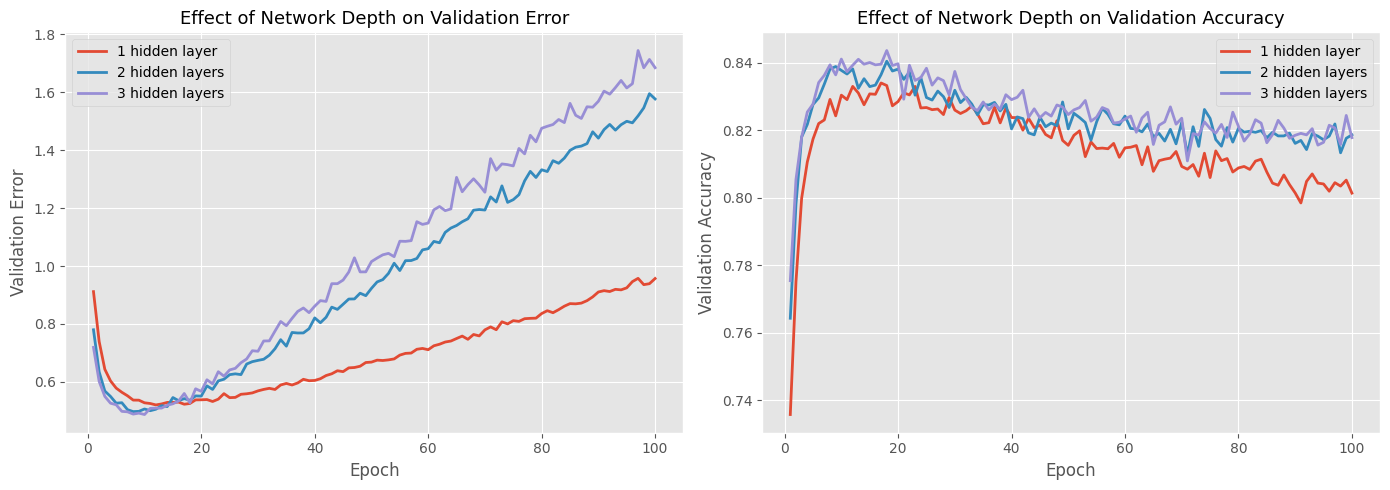

In [51]:
# comparison plot
fig = plt.figure(figsize=(14, 5))

# validation errors
ax1 = fig.add_subplot(1, 2, 1)

stats_1 = results_1layer['stats']
keys_1 = results_1layer['keys']
epochs_1 = np.arange(1, stats_1.shape[0])
valid_error_1 = stats_1[1:, keys_1['error(valid)']]
ax1.plot(epochs_1, valid_error_1, label='1 hidden layer', linewidth=2)

stats_2 = results_2layer['stats']
keys_2 = results_2layer['keys']
epochs_2 = np.arange(1, stats_2.shape[0])
valid_error_2 = stats_2[1:, keys_2['error(valid)']]
ax1.plot(epochs_2, valid_error_2, label='2 hidden layers', linewidth=2)

stats_3 = results_3layer['stats']
keys_3 = results_3layer['keys']
epochs_3 = np.arange(1, stats_3.shape[0])
valid_error_3 = stats_3[1:, keys_3['error(valid)']]
ax1.plot(epochs_3, valid_error_3, label='3 hidden layers', linewidth=2)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Validation Error', fontsize=12)
ax1.set_title('Effect of Network Depth on Validation Error', fontsize=13)
ax1.legend()
ax1.grid(True)

# validation accuracies
ax2 = fig.add_subplot(1, 2, 2)

valid_acc_1 = stats_1[1:, keys_1['acc(valid)']]
ax2.plot(epochs_1, valid_acc_1, label='1 hidden layer', linewidth=2)

valid_acc_2 = stats_2[1:, keys_2['acc(valid)']]
ax2.plot(epochs_2, valid_acc_2, label='2 hidden layers', linewidth=2)

valid_acc_3 = stats_3[1:, keys_3['acc(valid)']]
ax2.plot(epochs_3, valid_acc_3, label='3 hidden layers', linewidth=2)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Validation Accuracy', fontsize=12)
ax2.set_title('Effect of Network Depth on Validation Accuracy', fontsize=13)
ax2.legend()
ax2.grid(True)

fig.tight_layout()
fig.savefig('depth_comparison.pdf')
plt.show()

In [ ]:
print("Width Experiments Results")
print("Number of Hidden Units  |Val. Acc. |Train Error| Val. Error")



# Get results for 32 units
val_acc_32 = results_32['stats'][-1, results_32['keys']['acc(valid)']]
train_err_32 = results_32['stats'][-1, results_32['keys']['error(train)']]
val_err_32 = results_32['stats'][-1, results_32['keys']['error(valid)']]

# Convert to percentage and format
val_acc_32_percent = val_acc_32 * 100
print("32 units                |   {:.1f}   |  {:.3f}  |   {:.3f}".format(
    val_acc_32_percent, train_err_32, val_err_32))

# Get results for 64 units
val_acc_64 = results_64['stats'][-1, results_64['keys']['acc(valid)']]
train_err_64 = results_64['stats'][-1, results_64['keys']['error(train)']]
val_err_64 = results_64['stats'][-1, results_64['keys']['error(valid)']]

val_acc_64_percent = val_acc_64 * 100
print("64 units                |   {:.1f}   |  {:.3f}  |   {:.3f}".format(
    val_acc_64_percent, train_err_64, val_err_64))

# Get results for 128 units
val_acc_128 = results_128['stats'][-1, results_128['keys']['acc(valid)']]
train_err_128 = results_128['stats'][-1, results_128['keys']['error(train)']]
val_err_128 = results_128['stats'][-1, results_128['keys']['error(valid)']]

val_acc_128_percent = val_acc_128 * 100
print("128 units               |   {:.1f}   |  {:.3f}  |   {:.3f}".format(
    val_acc_128_percent, train_err_128, val_err_128))

Width Experiments Results
Number of Hidden Units  |Val. Acc. |Train Error| Val. Error
32 units                |   78.7   |  0.552  |   0.697
64 units                |   79.8   |  0.358  |   0.711
128 units               |   81.2   |  0.157  |   0.940


In [59]:
print("Depth Experiments Results")
print("Number of Hidden Layers | Val. Acc.|Train Error| Val. Error")

# Get results for 1 layer
val_acc_1 = results_1layer['stats'][-1, results_1layer['keys']['acc(valid)']]
train_err_1 = results_1layer['stats'][-1, results_1layer['keys']['error(train)']]
val_err_1 = results_1layer['stats'][-1, results_1layer['keys']['error(valid)']]

val_acc_1_percent = val_acc_1 * 100
print("1 hidden layer          |   {:.1f}   |  {:.3f}  |   {:.3f}".format(
    val_acc_1_percent, train_err_1, val_err_1))

# Get results for 2 layers
val_acc_2 = results_2layer['stats'][-1, results_2layer['keys']['acc(valid)']]
train_err_2 = results_2layer['stats'][-1, results_2layer['keys']['error(train)']]
val_err_2 = results_2layer['stats'][-1, results_2layer['keys']['error(valid)']]

val_acc_2_percent = val_acc_2 * 100
print("2 hidden layers         |   {:.1f}   |  {:.3f}  |   {:.3f}".format(
    val_acc_2_percent, train_err_2, val_err_2))

# Get results for 3 layers
val_acc_3 = results_3layer['stats'][-1, results_3layer['keys']['acc(valid)']]
train_err_3 = results_3layer['stats'][-1, results_3layer['keys']['error(train)']]
val_err_3 = results_3layer['stats'][-1, results_3layer['keys']['error(valid)']]

val_acc_3_percent = val_acc_3 * 100
print("3 hidden layers         |   {:.1f}   |  {:.3f}  |   {:.3f}".format(
    val_acc_3_percent, train_err_3, val_err_3))

Depth Experiments Results
Number of Hidden Layers | Val. Acc.|Train Error| Val. Error
1 hidden layer          |   80.1   |  0.160  |   0.957
2 hidden layers         |   81.9   |  0.087  |   1.577
3 hidden layers         |   81.8   |  0.109  |   1.684


## Problematic Training

The following experiments show a failed training run. Run the code and investigate the reasons.

Exp Prog:   0%|          | 0/5 [00:00<?, ?it/s]








































Ep Prog: 100%|██████████| 1000/1000 [00:04<00:00, 234.49it/s]
Epoch 1: 4.3s to complete
    error(train)=3.85e+00, acc(train)=2.15e-02, error(valid)=3.85e+00, acc(valid)=1.99e-02
Exp Prog:  20%|██        | 1/5 [00:05<00:22,  5.67s/it]









































Ep Prog: 100%|██████████| 1000/1000 [00:04<00:00, 230.84it/s]
Epoch 2: 4.3s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=1.96e-02
Exp Prog:  40%|████      | 2/5 [00:11<00:17,  5.70s/it]





































Ep Prog: 100%|██████████| 1000/1000 [00:03<00:00, 260.97it/s]
Epoch 3: 3.8s to complete
    error(train)=3.80e+00, acc(train)=4.27e-02, error(valid)=3.80e+00, acc(valid)=4.32e-02
Exp Prog:  60%|██████    | 3/5 [00:16<00:11,  5.52s/it]






































Ep Prog: 100%|██████████| 1000/1000 [00:04<00:00, 243.66it/s]
Epoch 4: 4.1s to complete
   

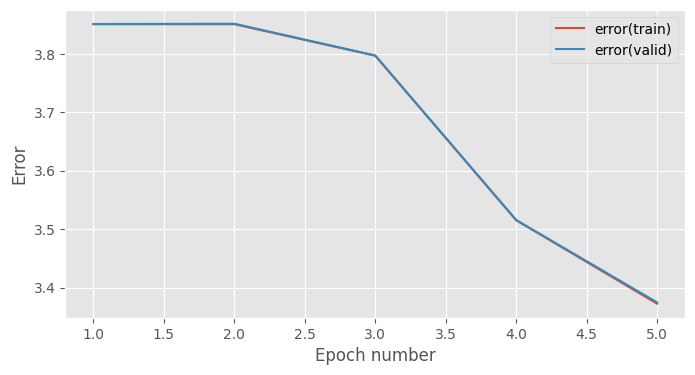

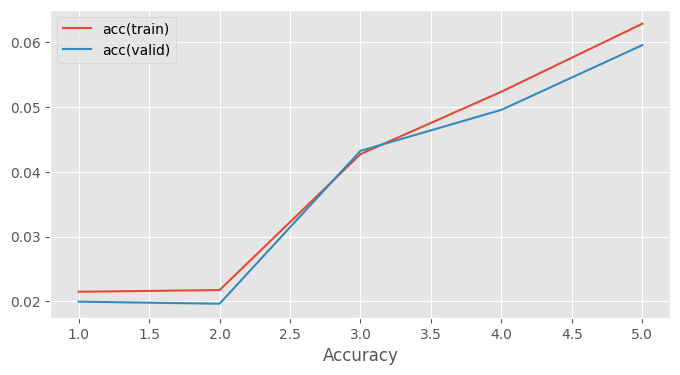

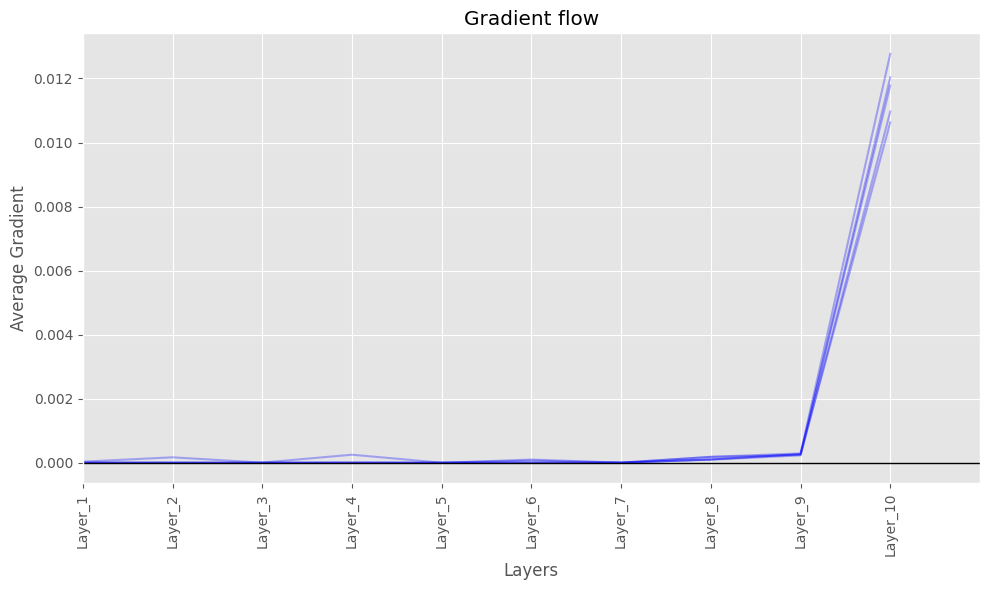

In [61]:
# Setup hyperparameters
learning_rate = 0.001
num_epochs = 5
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with four hidden layer
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    CustomActivationLayer(), 
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=False)

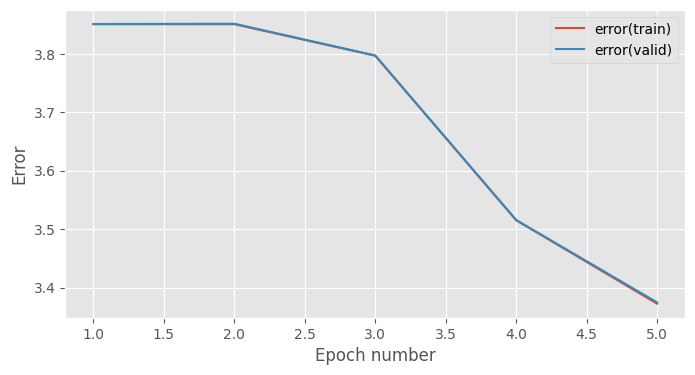

In [62]:
# You can then check the plots like this
fig_1 # The training error plot

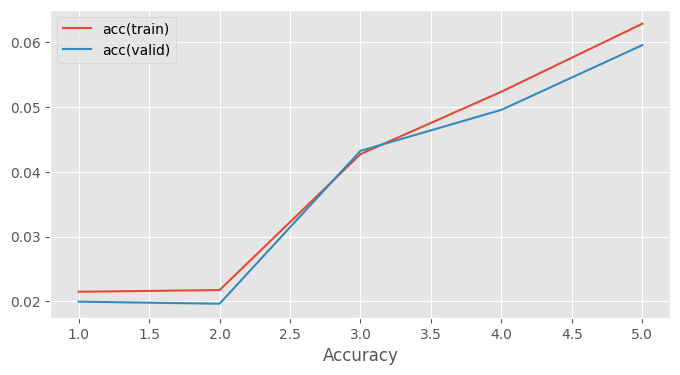

In [63]:
fig_2 # The training accuracy plot

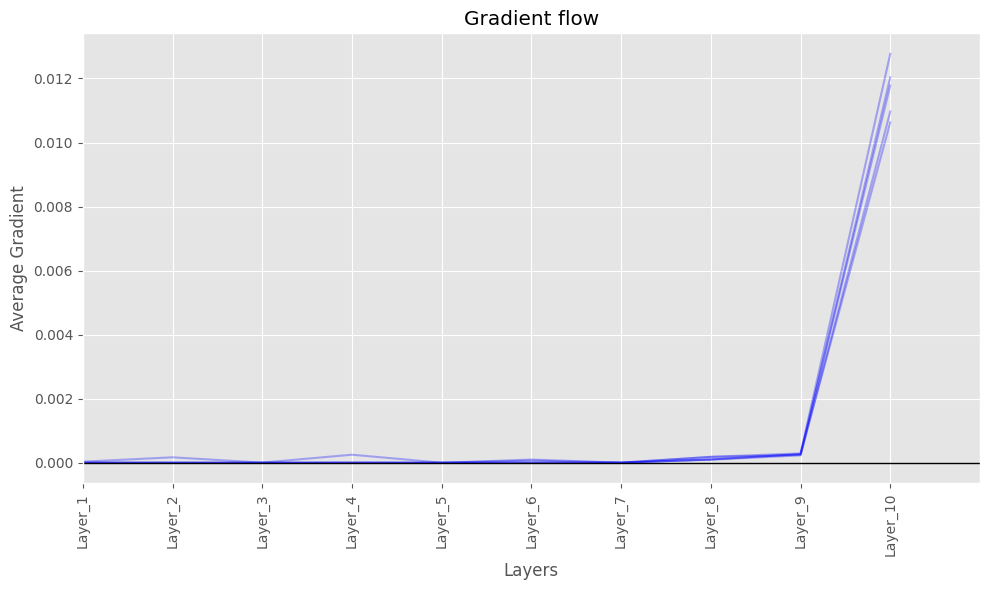

In [64]:
grad_plot # The gradient flow plot

Training baseline (3 hidden layers, 128 units, lr=0.0001)


Ep Prog: 100%|██████████| 1000/1000 [00:04<00:00, 211.07it/s]
Epoch 1: 4.7s to complete
    error(train)=1.35e+00, acc(train)=6.22e-01, error(valid)=1.36e+00, acc(valid)=6.20e-01
Ep Prog: 100%|██████████| 1000/1000 [00:03<00:00, 265.50it/s]
Epoch 2: 3.8s to complete
    error(train)=1.11e+00, acc(train)=6.85e-01, error(valid)=1.12e+00, acc(valid)=6.79e-01
Ep Prog: 100%|██████████| 1000/1000 [00:03<00:00, 254.50it/s]
Epoch 3: 3.9s to complete
    error(train)=9.85e-01, acc(train)=7.14e-01, error(valid)=9.96e-01, acc(valid)=7.06e-01
Ep Prog: 100%|██████████| 1000/1000 [00:03<00:00, 275.89it/s]
Epoch 4: 3.6s to complete
    error(train)=8.92e-01, acc(train)=7.40e-01, error(valid)=9.06e-01, acc(valid)=7.31e-01
Ep Prog: 100%|██████████| 1000/1000 [00:03<00:00, 274.21it/s]
Epoch 5: 3.7s to complete
    error(train)=8.18e-01, acc(train)=7.60e-01, error(valid)=8.32e-01, acc(valid)=7.54e-01
Ep Prog: 100%|██████████| 1000/1000 [00:03<00:00, 322.74it/s]
Epoch 6: 3.1s to complete
    error(train)=

Baseline - Valid Error: 0.5218907319264707
Baseline - Valid Acc: 0.840253164556962


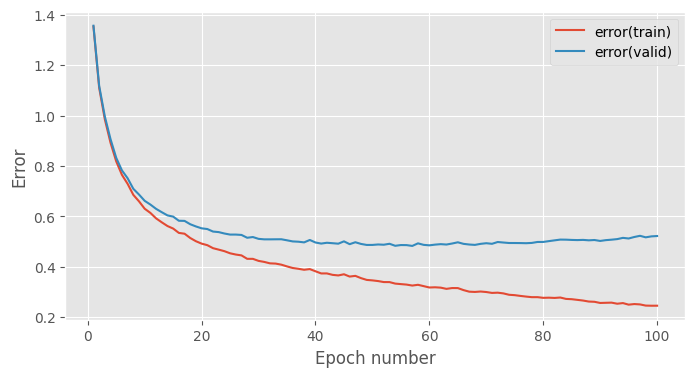

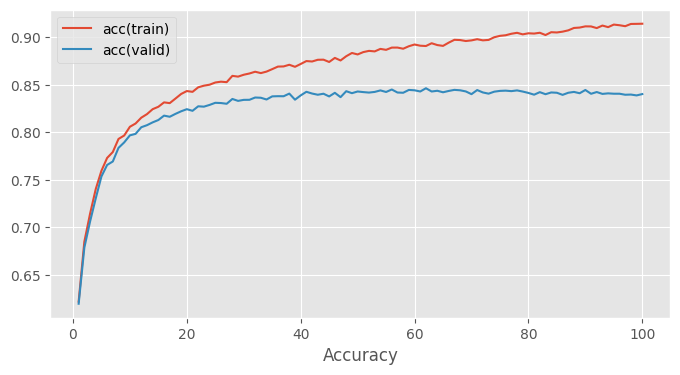

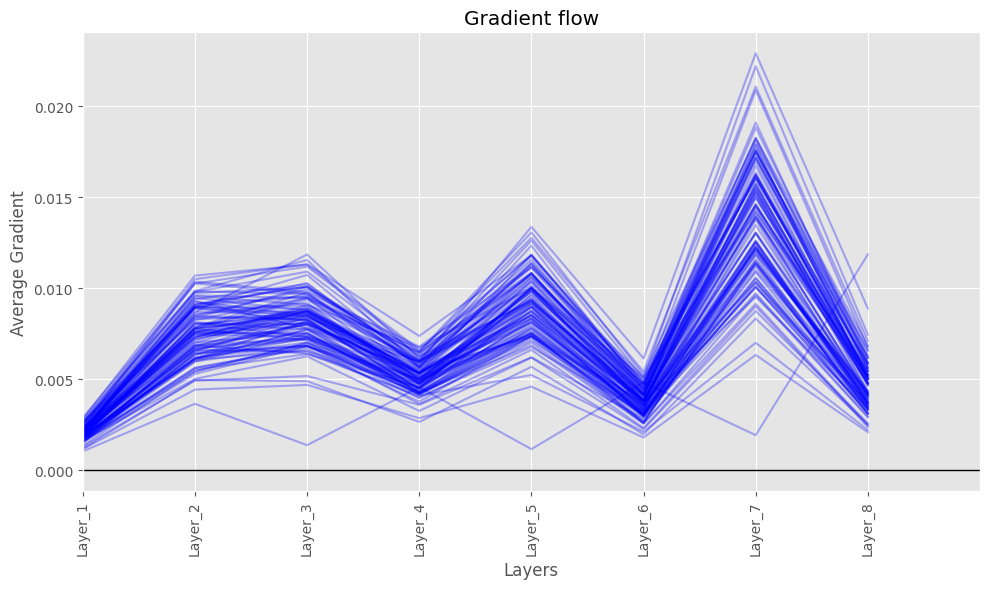

In [11]:
# Trainining baseline model for regularization experiments
print("Training baseline (3 hidden layers, 128 units, lr=0.0001)")

input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

train_data.reset()
valid_data.reset()

layer1 = AffineLayer(input_dim, 128, weights_init, biases_init)
activation1 = ReluLayer()
layer2 = AffineLayer(128, 128, weights_init, biases_init)
activation2 = ReluLayer()
layer3 = AffineLayer(128, 128, weights_init, biases_init)
activation3 = ReluLayer()
layer_out = AffineLayer(128, output_dim, weights_init, biases_init)

layers = [layer1, activation1, layer2, activation2, layer3, activation3, layer_out]
model = MultipleLayerModel(layers)

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=0.0001)

stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, 100, 1, notebook=False)

baseline_stats = stats
baseline_keys = keys

print("Baseline - Valid Error:", stats[-1, keys['error(valid)']])
print("Baseline - Valid Acc:", stats[-1, keys['acc(valid)']])

In [8]:
from mlp.layers import DropoutLayer

print("Training with Dropout (p=0.3)")
train_data.reset()
valid_data.reset()

input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

layer1 = AffineLayer(input_dim, 128, weights_init, biases_init)
activation1 = ReluLayer()
dropout1 = DropoutLayer(rng=rng, incl_prob=0.3)

layer2 = AffineLayer(128, 128, weights_init, biases_init)
activation2 = ReluLayer()
dropout2 = DropoutLayer(rng=rng, incl_prob=0.3)

layer3 = AffineLayer(128, 128, weights_init, biases_init)
activation3 = ReluLayer()
dropout3 = DropoutLayer(rng=rng, incl_prob=0.3)

layer_out = AffineLayer(128, output_dim, weights_init, biases_init)

layers = [layer1, activation1, dropout1, layer2, activation2, dropout2, 
          layer3, activation3, dropout3, layer_out]
model = MultipleLayerModel(layers)

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=0.0001)

stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, 100, 1, notebook=False)

dropout_03_stats = stats
dropout_03_keys = keys

print("Dropout 0.3 - Valid Error:", stats[-1, keys['error(valid)']])
print("Dropout 0.3 - Valid Acc:", stats[-1, keys['acc(valid)']])

Training with Dropout (p=0.3)


NotImplementedError: 

In [9]:
import mlp.layers
import os
from mlp.layers import DropoutLayer


print("Python is loading mlp from:")
print(mlp.layers.__file__)

# Open this file to verify your changes are there
layers_path = mlp.layers.__file__
print("\nYou need to edit THIS file:")
print(layers_path)

# Check if it's a .pyc file (compiled)
if layers_path.endswith('.pyc'):
    # Point to the .py file instead
    layers_path = layers_path[:-1]  # Remove 'c' from '.pyc'
    print("\nActual source file:")
    print(layers_path)

# Check if file exists
if os.path.exists(layers_path):
    print("\n✓ File exists")
    
    # Read a portion of the file to check implementation
    with open(layers_path, 'r') as f:
        print(layers_path)
        content = f.read()
        
    # Check if DropoutLayer exists
    if 'class DropoutLayer' in content:
        print("✓ DropoutLayer class found")
        
        # Check if fprop is implemented
        if 'raise NotImplementedError' in content and 'DropoutLayer' in content:
            print("✗ fprop still has NotImplementedError - YOU NEED TO EDIT THIS FILE")
        else:
            print("✓ fprop appears to be implemented")
    else:
        print("✗ DropoutLayer class not found in file")
else:
    print("✗ File does not exist!")

Python is loading mlp from:
c:\Users\Ash\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlp-0.0.0-py3.13.egg\mlp\layers.py

You need to edit THIS file:
c:\Users\Ash\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlp-0.0.0-py3.13.egg\mlp\layers.py
✗ File does not exist!


In [2]:
# Remove all mlp modules from cache
import sys
modules_to_remove = [key for key in sys.modules.keys() if key.startswith('mlp')]
for module in modules_to_remove:
    del sys.modules[module]

print(f"Removed {len(modules_to_remove)} cached modules")

# Now reimport
import os
sys.path.insert(0, os.getcwd())
os.environ['MLP_DATA_DIR'] = os.path.join(os.getcwd(), 'data')
print(os.environ['MLP_DATA_DIR'])

from mlp.layers import DropoutLayer
import inspect

# Check the implementation
print("\nChecking DropoutLayer.fprop:")
source = inspect.getsource(DropoutLayer.fprop)
if 'NotImplementedError' in source:
    print("❌ STILL NOT IMPLEMENTED")
    print("\nShowing first 500 chars of fprop:")
    print(source[:1000])
else:
    print("✓ Implementation found!")
    print("\nFirst 200 chars:")
    print(source[:200])

Removed 3 cached modules
d:\MSc\MLP\mlpractical\mlpractical\notebooks\data

Checking DropoutLayer.fprop:
❌ STILL NOT IMPLEMENTED

Showing first 500 chars of fprop:
    def fprop(self, inputs, stochastic=True):
        """Forward propagates activations through the layer transformation.

        Args:
            inputs: Array of layer inputs of shape (batch_size, input_dim).
            stochastic: Flag allowing different deterministic
                forward-propagation mode in addition to default stochastic
                forward-propagation e.g. for use at test time. If False
                a deterministic forward-propagation transformation
                corresponding to the expected output of the stochastic
                forward-propagation is applied.

        Returns:
            outputs: Array of layer outputs of shape (batch_size, output_dim).
        """
        raise NotImplementedError



In [1]:
%pip uninstall mlp -y


Found existing installation: mlp 0.0.0
Uninstalling mlp-0.0.0:
Note: you may need to restart the kernel to use updated packages.


ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\Ash\AppData\Local\Programs\Python\Python313\Lib\shutil.py", line 856, in move
    os.rename(src, real_dst)
    ~~~~~~~~~^^^^^^^^^^^^^^^
PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\users\\ash\\appdata\\local\\programs\\python\\python313\\lib\\site-packages\\mlp-0.0.0-py3.13.egg' -> 'C:\\Users\\Ash\\AppData\\Local\\Temp\\pip-uninstall-bvr0wd7c\\mlp-0.0.0-py3.13.egg'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\Ash\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_internal\cli\base_command.py", line 107, in _run_wrapper
    status = _inner_run()
  File "c:\Users\Ash\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_internal\cli\base_command.py", line 98, in _inner_run
    return self.run(options, args)
           ~~~~~~~~^^^^^^^^^^^^^^^
  File "c:\

In [2]:
%pip install mlp

Note: you may need to restart the kernel to use updated packages.
